# Display Event 61 (pulseH[22]) histogram

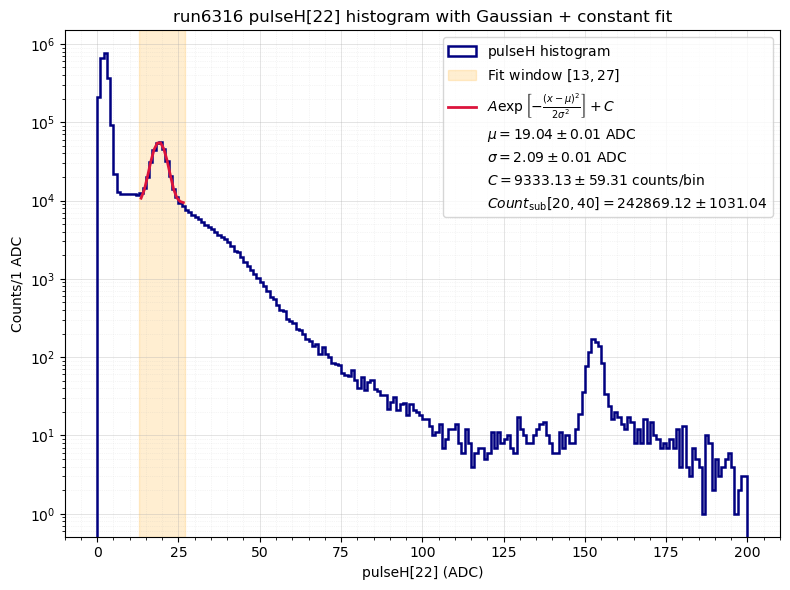

Loaded 2684563 finite pulseH[22] entries from run30447_processed_v5.root
Peak location in fit window (13, 27): 19.500
Fitted amplitude: 46416.282 +/- 140.209
Fitted mean: 19.039 +/- 0.006
Fitted sigma: 2.088 +/- 0.007
Fitted background (constant term): 9333.135 +/- 59.312 counts/bin
Raw histogram sum in [13, 27]: 373533.000
Background contribution over 14 bins: 130663.884
Background-subtracted sum in [13, 27]: 242869.116 +/- 1031.038


In [5]:
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import uproot
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

path_of_run = Path("/raid1/genli/Data_D2O/M1_data/run30447_processed_v5.root")
channel_index = 22
hist_range = (0, 200)
bins = 200
fit_range = (13, 27)

if not path_of_run.exists():
    raise FileNotFoundError(f"Missing ROOT file: {path_of_run}")

with uproot.open(path_of_run) as root_file:
    pulseh = root_file["tree"]["pulseH"].array(library="ak")

pulseh_ch22 = ak.to_numpy(pulseh[:, channel_index])
pulseh_ch22 = pulseh_ch22[np.isfinite(pulseh_ch22)]

hist_counts, bin_edges = np.histogram(pulseh_ch22, bins=bins, range=hist_range)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]

fit_mask = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1])
fit_x = bin_centers[fit_mask]
fit_y = hist_counts[fit_mask].astype(float)

if fit_y.size == 0 or np.all(fit_y == 0):
    raise ValueError(f"No histogram content found in fit range {fit_range}")

peak_index = int(np.argmax(fit_y))
peak_location = float(fit_x[peak_index])
background_guess = float(np.min(fit_y))
amplitude_guess = float(max(fit_y[peak_index] - background_guess, 1.0))
sigma_guess = 3.0

def gaussian_plus_constant(x, amplitude, mean, sigma, constant):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2) + constant

fit_sigma = np.sqrt(np.maximum(fit_y, 1.0))
fit_params, fit_cov = curve_fit(
    gaussian_plus_constant,
    fit_x,
    fit_y,
    p0=(amplitude_guess, peak_location, sigma_guess, background_guess),
    sigma=fit_sigma,
    absolute_sigma=True,
    bounds=(
        (0.0, fit_range[0], 0.1, 0.0),
        (np.inf, fit_range[1], fit_range[1] - fit_range[0], np.inf),
    ),
    maxfev=10000,
 )

fit_errors = np.sqrt(np.clip(np.diag(fit_cov), 0.0, None))
amplitude_fit, mean_fit, sigma_fit, background_fit = fit_params
amplitude_err, mean_err, sigma_err, background_err = fit_errors
fit_curve = gaussian_plus_constant(fit_x, *fit_params)

raw_window_sum = float(np.sum(fit_y))
background_total = float(background_fit * fit_y.size)
background_subtracted_sum = raw_window_sum - background_total
background_subtracted_err = float(np.sqrt(raw_window_sum + (fit_y.size * background_err) ** 2))

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(
    pulseh_ch22,
    bins=bins,
    range=hist_range,
    histtype="step",
    linewidth=1.8,
    color="navy",
    label=r"$\mathrm{pulseH\ histogram}$",
)
ax.axvspan(
    fit_range[0],
    fit_range[1],
    color="orange",
    alpha=0.18,
    label=rf"$\mathrm{{Fit\ window}}\ [{fit_range[0]}, {fit_range[1]}]$",
)
ax.plot(
    fit_x,
    fit_curve,
    color="crimson",
    linewidth=2.0,
    label=r"$A\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right] + C$",
)
legend_handles, _ = ax.get_legend_handles_labels()
legend_handles.extend(
    [
        Line2D([], [], color="none", label=rf"$\mu = {mean_fit:.2f} \pm {mean_err:.2f}\ \mathrm{{ADC}}$"),
        Line2D([], [], color="none", label=rf"$\sigma = {sigma_fit:.2f} \pm {sigma_err:.2f}\ \mathrm{{ADC}}$"),
        Line2D([], [], color="none", label=rf"$C = {background_fit:.2f} \pm {background_err:.2f}\ \mathrm{{counts/bin}}$"),
        Line2D([], [], color="none", label=rf"$Count_{{\mathrm{{sub}}}}[20,40] = {background_subtracted_sum:.2f} \pm {background_subtracted_err:.2f}$"),
    ]
)
ax.set_yscale("log")
ax.set_xlabel(f"pulseH[{channel_index}] (ADC)")
ax.set_ylabel(f"Counts/{bin_width:g} ADC")
ax.set_title("run6316 pulseH[22] histogram with Gaussian + constant fit")
ax.grid(True, which="major", linestyle="-", linewidth=0.7, alpha=0.35)
ax.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.25)
ax.minorticks_on()
ax.legend(handles=legend_handles, loc="upper right")
plt.tight_layout()
plt.show()

print(f"Loaded {pulseh_ch22.size} finite pulseH[{channel_index}] entries from {path_of_run.name}")
print(f"Peak location in fit window {fit_range}: {peak_location:.3f}")
print(f"Fitted amplitude: {amplitude_fit:.3f} +/- {amplitude_err:.3f}")
print(f"Fitted mean: {mean_fit:.3f} +/- {mean_err:.3f}")
print(f"Fitted sigma: {sigma_fit:.3f} +/- {sigma_err:.3f}")
print(f"Fitted background (constant term): {background_fit:.3f} +/- {background_err:.3f} counts/bin")
print(f"Raw histogram sum in [{fit_range[0]}, {fit_range[1]}]: {raw_window_sum:.3f}")
print(f"Background contribution over {fit_y.size} bins: {background_total:.3f}")
print(f"Background-subtracted sum in [{fit_range[0]}, {fit_range[1]}]: {background_subtracted_sum:.3f} +/- {background_subtracted_err:.3f}")